# Trabalho 1 — Mineração de dados com dados do IBGE

**Alunas:** Karoline da Silva Couto e Livia de Paula

O objetivo deste exercício é explorar, tratar e visualizar dados públicos do Brasil disponibilizados pelo IBGE, aplicando técnicas de mineração de dados e construção de gráficos estatísticos.

## Fontes e recortes utilizados

- **PIB dos Municípios:** valores de 2023 previamente agregados por Unidade da Federação, em milhares de reais.
- **SIDRA/PNAD Contínua — Tabela 5919:** percentual da população com ensino superior completo ou equivalente nos quatro trimestres de 2023.
- **Projeções da População — Revisão 2024:** população por sexo e idade simples, de 2000 a 2070, para Brasil, regiões e UFs.
- **API de Malhas Geográficas do IBGE:** limites simplificados das Unidades da Federação para o mapa coroplético.

O nível comum de integração é a **Unidade da Federação (UF)**. O PIB per capita é calculado dividindo o PIB estadual de 2023 pela população projetada da mesma UF em 2023.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

caminho1 = Path("datas/PIBMunicipios.csv")
caminho2 = Path("datas/tabela_ensino.xlsx")
caminho3 = Path("datas/projecoes_2024.xlsx")

df_pib = pd.read_csv(caminho1, sep=';', skiprows=1, nrows=1, encoding='utf-8')
df_educacao = pd.read_excel(caminho2, skiprows=4)
df_populacao = pd.read_excel(caminho3, skiprows=5, index_col=0)

df_populacao_completa = df_populacao.copy()

In [2]:
print("Quantidade de linhas e colunas:", df_populacao.shape)

df_populacao.info()

print('Quantidade de duplicatas: ', df_populacao.duplicated().sum())

Quantidade de linhas e colunas: (9009, 75)
<class 'pandas.DataFrame'>
Index: 9009 entries, 0 to 90
Data columns (total 75 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   SEXO    9009 non-null   str  
 1   CÓD.    9009 non-null   int64
 2   SIGLA   9009 non-null   str  
 3   LOCAL   9009 non-null   str  
 4   2000    9009 non-null   int64
 5   2001    9009 non-null   int64
 6   2002    9009 non-null   int64
 7   2003    9009 non-null   int64
 8   2004    9009 non-null   int64
 9   2005    9009 non-null   int64
 10  2006    9009 non-null   int64
 11  2007    9009 non-null   int64
 12  2008    9009 non-null   int64
 13  2009    9009 non-null   int64
 14  2010    9009 non-null   int64
 15  2011    9009 non-null   int64
 16  2012    9009 non-null   int64
 17  2013    9009 non-null   int64
 18  2014    9009 non-null   int64
 19  2015    9009 non-null   int64
 20  2016    9009 non-null   int64
 21  2017    9009 non-null   int64
 22  2018    9009 non-null  

In [3]:
print("Quantidade de linhas e colunas:", df_pib.shape)

df_pib.info()

print('Quantidade de duplicatas:', df_pib.duplicated().sum())

Quantidade de linhas e colunas: (1, 27)
<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Acre                 1 non-null      int64
 1   Alagoas              1 non-null      int64
 2   Amapá                1 non-null      int64
 3   Amazonas             1 non-null      int64
 4   Bahia                1 non-null      int64
 5   Ceará                1 non-null      int64
 6   Distrito Federal     1 non-null      int64
 7   Espírito Santo       1 non-null      int64
 8   Goiás                1 non-null      int64
 9   Maranhão             1 non-null      int64
 10  Mato Grosso          1 non-null      int64
 11  Mato Grosso do Sul   1 non-null      int64
 12  Minas Gerais         1 non-null      int64
 13  Paraná               1 non-null      int64
 14  Paraíba              1 non-null      int64
 15  Pará                 1 non-null      int64
 16  P

In [4]:
print("Quantidade de linhas e colunas:", df_educacao.shape)

df_educacao.info()

print('Quantidade de duplicatas:', df_educacao.duplicated().sum())

Quantidade de linhas e colunas: (28, 5)
<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Unnamed: 0                                 28 non-null     str    
 1   Ensino superior completo ou equivalente    27 non-null     float64
 2   Ensino superior completo ou equivalente.1  27 non-null     float64
 3   Ensino superior completo ou equivalente.2  27 non-null     float64
 4   Ensino superior completo ou equivalente.3  27 non-null     float64
dtypes: float64(4), str(1)
memory usage: 1.2 KB
Quantidade de duplicatas: 0


## Tratamento e integração dos dados

### Função auxiliar

In [5]:
def formato_brl(valor):
    return f'R$ {valor:,.2f}'

### Tratamento da população

In [6]:
df_populacao = df_populacao[['SEXO','LOCAL', 2023]]

df_populacao_por_uf = df_populacao[df_populacao['SEXO'] == 'Ambos']

df_populacao_por_uf = df_populacao_por_uf[['LOCAL', 2023]].groupby('LOCAL').sum()

df_populacao_por_uf.index.name = None

df_populacao_por_uf = df_populacao_por_uf.drop(index=['Brasil', 'Norte', 'Nordeste', 'Sul', 'Sudeste', 'Centro-Oeste'])

df_populacao_por_uf.columns = ['populacao em 2023']

display(df_populacao_por_uf)


,populacao em 2023
Acre,876582
Alagoas,3218607
Amapá,799124
Amazonas,4240571
Bahia,14828806
Ceará,9196672
Distrito Federal,2967543
Espírito Santo,4076068
Goiás,7274463
Maranhão,7003234


### Tratamento do PIB

In [7]:
df_pib_copy = df_pib.copy()

df_pib_copy = df_pib_copy.T

df_pib_copy.columns = ['pib_mil_reais']

#df_pib_copy['pib_bilhoes'] = df_pib_copy['pib'] / 1_000_000

df_pib_copy = df_pib_copy.sort_values(by='pib_mil_reais', ascending= False)

display(df_pib_copy)

,pib_mil_reais
São Paulo,3444814033
Rio de Janeiro,1172871443
Minas Gerais,971977551
Paraná,670919162
Rio Grande do Sul,650107022
Santa Catarina,513392973
Bahia,430987853
Distrito Federal,365669108
Goiás,336746975
Mato Grosso,273008586


### Normalização: PIB per capita

In [8]:
df_pib_capita = df_pib_copy.join(df_populacao_por_uf)

df_pib_capita['pib_per_capita'] = (df_pib_capita['pib_mil_reais'] * 1000) / (df_pib_capita['populacao em 2023'])

display(df_pib_capita)

,pib_mil_reais,populacao em 2023,pib_per_capita
São Paulo,3444814033,45850570,75131.324060
Rio de Janeiro,1172871443,17213813,68135.481837
Minas Gerais,971977551,21247401,45745.715017
Paraná,670919162,11753862,57080.741802
Rio Grande do Sul,650107022,11222292,57929.968495
Santa Catarina,513392973,7927212,64763.371157
Bahia,430987853,14828806,29064.231672
Distrito Federal,365669108,2967543,123222.850688
Goiás,336746975,7274463,46291.660979
Mato Grosso,273008586,3778389,72255.288166


### Tratamento da escolaridade

In [9]:
df_educacao_copy = df_educacao.set_index(df_educacao.columns[0])

df_educacao_copy.index.name = None

df_educacao_copy = (df_educacao_copy.mean(axis=1).dropna().to_frame('percentual superior completo (%)'))

df_educacao_copy = df_educacao_copy.sort_values(by='percentual superior completo (%)', ascending=False)

display(df_educacao_copy)

,percentual superior completo (%)
Distrito Federal,28.325
São Paulo,18.950
Rio de Janeiro,18.800
Mato Grosso do Sul,16.300
Santa Catarina,15.700
Amapá,15.525
Paraná,15.325
Rio Grande do Sul,14.600
Goiás,14.350
Espírito Santo,14.300


### Integração: escolaridade e PIB per capita

In [10]:
df_educacao_pib_capita = df_pib_capita.join(df_educacao_copy)

df_educacao_pib_capita = df_educacao_pib_capita[['pib_per_capita', 'percentual superior completo (%)']]

display(df_educacao_pib_capita)

,pib_per_capita,percentual superior completo (%)
São Paulo,75131.324060,18.950
Rio de Janeiro,68135.481837,18.800
Minas Gerais,45745.715017,13.225
Paraná,57080.741802,15.325
Rio Grande do Sul,57929.968495,14.600
Santa Catarina,64763.371157,15.700
Bahia,29064.231672,8.525
Distrito Federal,123222.850688,28.325
Goiás,46291.660979,14.350
Mato Grosso,72255.288166,13.450


### Agrupamento das UFs por região

Para comparar desigualdades regionais, cada Unidade da Federação é associada a uma das cinco Grandes Regiões do Brasil.

In [11]:
ufs_por_regiao = {
    'Norte': ['Acre', 'Amapá', 'Amazonas', 'Pará', 'Rondônia', 'Roraima', 'Tocantins'],
    'Nordeste': ['Alagoas', 'Bahia', 'Ceará', 'Maranhão', 'Paraíba', 'Pernambuco',
                 'Piauí', 'Rio Grande do Norte', 'Sergipe'],
    'Centro-Oeste': ['Distrito Federal', 'Goiás', 'Mato Grosso', 'Mato Grosso do Sul'],
    'Sudeste': ['Espírito Santo', 'Minas Gerais', 'Rio de Janeiro', 'São Paulo'],
    'Sul': ['Paraná', 'Rio Grande do Sul', 'Santa Catarina']
}

siglas_uf = {
    'Acre': 'AC', 'Alagoas': 'AL', 'Amapá': 'AP', 'Amazonas': 'AM', 'Bahia': 'BA',
    'Ceará': 'CE', 'Distrito Federal': 'DF', 'Espírito Santo': 'ES', 'Goiás': 'GO',
    'Maranhão': 'MA', 'Mato Grosso': 'MT', 'Mato Grosso do Sul': 'MS',
    'Minas Gerais': 'MG', 'Paraná': 'PR', 'Paraíba': 'PB', 'Pará': 'PA',
    'Pernambuco': 'PE', 'Piauí': 'PI', 'Rio Grande do Norte': 'RN',
    'Rio Grande do Sul': 'RS', 'Rio de Janeiro': 'RJ', 'Rondônia': 'RO',
    'Roraima': 'RR', 'Santa Catarina': 'SC', 'Sergipe': 'SE',
    'São Paulo': 'SP', 'Tocantins': 'TO'
}

regiao_por_uf = {
    uf: regiao
    for regiao, ufs in ufs_por_regiao.items()
    for uf in ufs
}

df_analise = df_educacao_pib_capita.copy()
df_analise['regiao'] = df_analise.index.map(regiao_por_uf)
df_analise['sigla'] = df_analise.index.map(siglas_uf)

assert df_analise['regiao'].notna().all(), 'Há UF sem região associada.'
assert df_analise[['pib_per_capita', 'percentual superior completo (%)']].notna().all().all(), 'Há valores ausentes após a integração.'

display(df_analise.head())

,pib_per_capita,percentual superior completo (%),regiao,sigla
São Paulo,75131.324060,18.950,Sudeste,SP
Rio de Janeiro,68135.481837,18.800,Sudeste,RJ
Minas Gerais,45745.715017,13.225,Sudeste,MG
Paraná,57080.741802,15.325,Sul,PR
Rio Grande do Sul,57929.968495,14.600,Sul,RS


## Análise exploratória e visualizações

In [12]:
df_educacao_pib_capita.describe()

,pib_per_capita,percentual superior completo (%)
count,27.000000,27.000000
mean,45025.873790,13.173148
std,22676.481564,4.251170
min,21308.326268,8.000000
25%,28745.968496,10.212500
50%,38154.054254,13.225000
75%,57505.355148,14.962500
max,123222.850688,28.325000


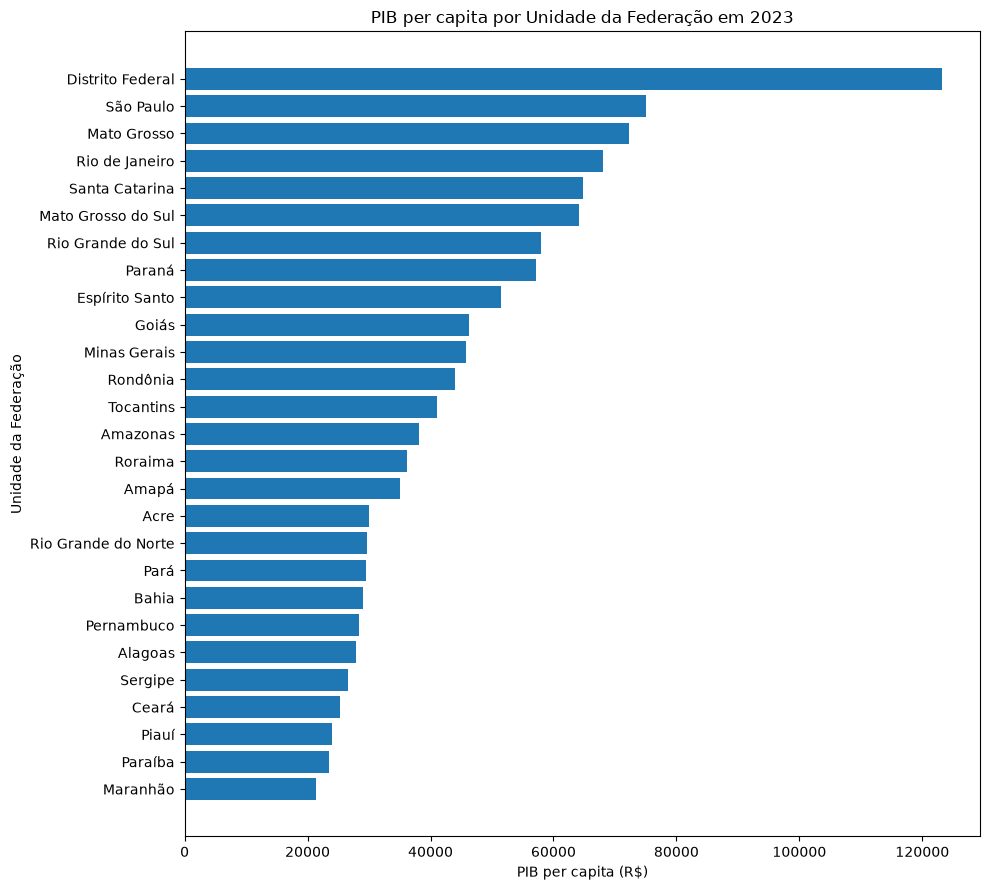

In [13]:
fig, ax = plt.subplots(figsize=(10, 9))

df_plot = df_pib_capita.sort_values(by='pib_per_capita', ascending=True)

ax.barh(df_plot.index, df_plot['pib_per_capita'])

ax.set_title('PIB per capita por Unidade da Federação em 2023')
ax.set_xlabel('PIB per capita (R$)')
ax.set_ylabel('Unidade da Federação')

plt.tight_layout()
plt.show()

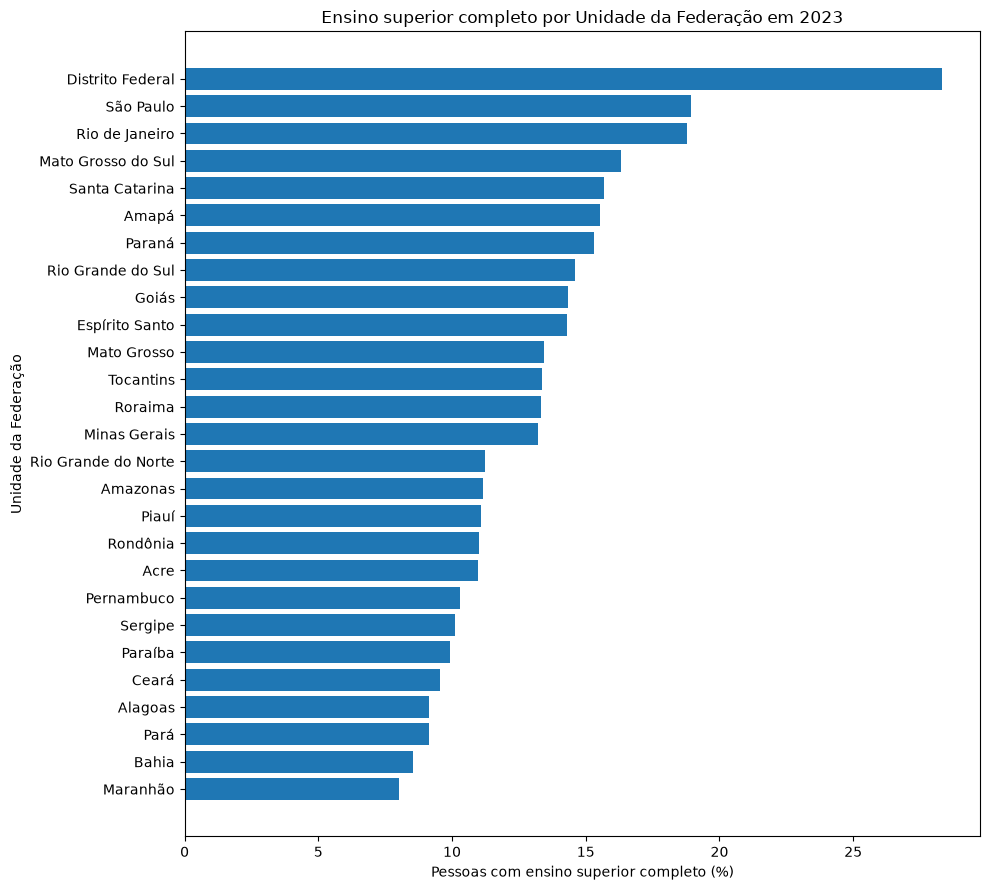

In [14]:
fig, ax = plt.subplots(figsize=(10, 9))

df_plot = df_educacao_copy.sort_values(by='percentual superior completo (%)', ascending=True)

ax.barh(df_plot.index, df_plot['percentual superior completo (%)'])

ax.set_title('Ensino superior completo por Unidade da Federação em 2023')
ax.set_xlabel('Pessoas com ensino superior completo (%)')
ax.set_ylabel('Unidade da Federação')

plt.tight_layout()
plt.show()

### Valores extremos

In [15]:
df_maior_pib = df_educacao_pib_capita.sort_values(by='pib_per_capita', ascending=False)

display(df_maior_pib.head(3))
display(df_maior_pib.tail(3))

,pib_per_capita,percentual superior completo (%)
Distrito Federal,123222.850688,28.325
São Paulo,75131.324060,18.950
Mato Grosso,72255.288166,13.450


,pib_per_capita,percentual superior completo (%)
Piauí,24040.319904,11.075
Paraíba,23509.255982,9.925
Maranhão,21308.326268,8.000


In [16]:
df_maior_educacao = df_educacao_pib_capita.sort_values(by='percentual superior completo (%)', ascending=False)

display(df_maior_educacao.head(3))
display(df_maior_educacao.tail(3))

,pib_per_capita,percentual superior completo (%)
Distrito Federal,123222.850688,28.325
São Paulo,75131.324060,18.950
Rio de Janeiro,68135.481837,18.800


,pib_per_capita,percentual superior completo (%)
Pará,29543.055459,9.125
Bahia,29064.231672,8.525
Maranhão,21308.326268,8.000


In [17]:
correlacao = df_educacao_pib_capita[['pib_per_capita', 'percentual superior completo (%)']].corr()

display(correlacao)

,pib_per_capita,percentual superior completo (%)
pib_per_capita,1.000000,0.929835
percentual superior completo (%),0.929835,1.000000


### Dispersão: PIB per capita × ensino superior completo

O gráfico de dispersão permite enxergar a direção e a intensidade da relação que a matriz de correlação apresentou. A linha tracejada representa apenas uma tendência linear dos dados.

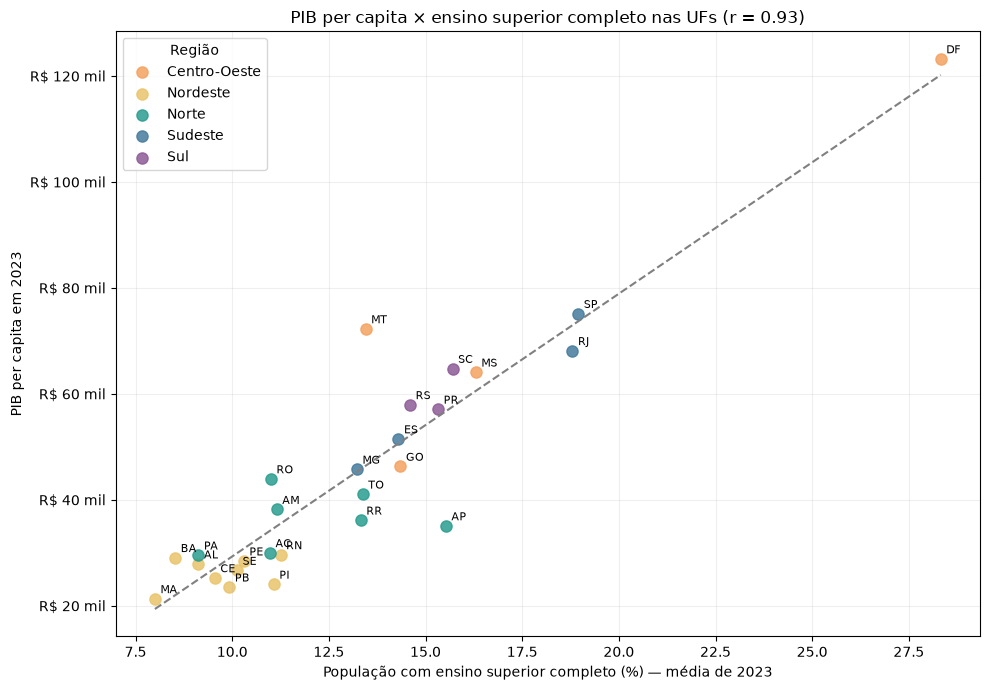

Correlação de Pearson: 0.930
Correlação sem o Distrito Federal: 0.863


In [18]:
from matplotlib.ticker import FuncFormatter

cores_regiao = {
    'Norte': '#2a9d8f',
    'Nordeste': '#e9c46a',
    'Centro-Oeste': '#f4a261',
    'Sudeste': '#457b9d',
    'Sul': '#8d5a97'
}

x = df_analise['percentual superior completo (%)']
y = df_analise['pib_per_capita']
correlacao_pearson = x.corr(y)
correlacao_sem_df = (
    df_analise.drop(index='Distrito Federal')['percentual superior completo (%)']
    .corr(df_analise.drop(index='Distrito Federal')['pib_per_capita'])
)

fig, ax = plt.subplots(figsize=(10, 7))

for regiao, grupo in df_analise.groupby('regiao'):
    ax.scatter(
        grupo['percentual superior completo (%)'],
        grupo['pib_per_capita'],
        s=65,
        alpha=0.85,
        color=cores_regiao[regiao],
        label=regiao
    )

coeficientes = np.polyfit(x, y, 1)
x_tendencia = np.linspace(x.min(), x.max(), 100)
ax.plot(x_tendencia, np.polyval(coeficientes, x_tendencia), '--', color='gray', linewidth=1.5)

for uf, linha in df_analise.iterrows():
    ax.annotate(
        linha['sigla'],
        (linha['percentual superior completo (%)'], linha['pib_per_capita']),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8
    )

ax.set_title(f'PIB per capita × ensino superior completo nas UFs (r = {correlacao_pearson:.2f})')
ax.set_xlabel('População com ensino superior completo (%) — média de 2023')
ax.set_ylabel('PIB per capita em 2023')
ax.yaxis.set_major_formatter(FuncFormatter(lambda valor, _: f'R$ {valor / 1000:.0f} mil'))
ax.grid(alpha=0.2)
ax.legend(title='Região')

plt.tight_layout()
plt.show()

print(f'Correlação de Pearson: {correlacao_pearson:.3f}')
print(f'Correlação sem o Distrito Federal: {correlacao_sem_df:.3f}')

A correlação de Pearson é positiva e forte (`r ≈ 0,93`): UFs com maior proporção de pessoas com ensino superior completo tendem a apresentar maior PIB per capita. O Distrito Federal é um ponto bem acima dos demais, mas, mesmo sem ele, a correlação permanece forte (`r ≈ 0,86`). Isso é uma associação, não uma prova de que uma variável causa a outra; estrutura produtiva, urbanização, mercado de trabalho e concentração de atividades públicas e privadas também podem influenciar o resultado.

### Linhas: evolução da população por região

A base selecionada informa a **população total**, sem separar população urbana e rural. Por isso, o gráfico usa o total de habitantes de cada região e deixa essa limitação explícita.

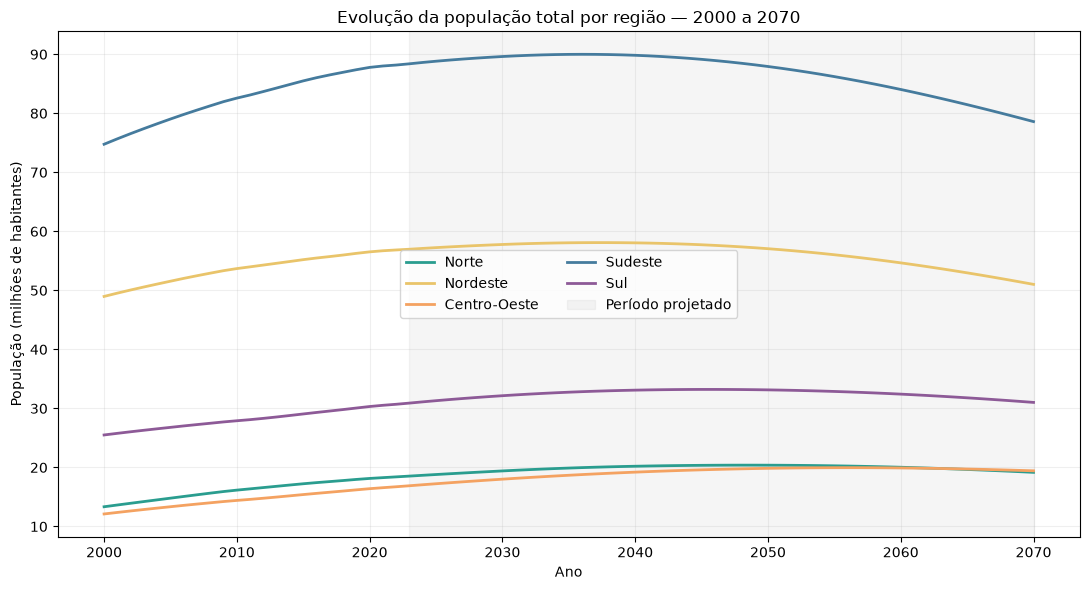

Pico projetado da população brasileira: 220.4 milhões em 2041.


In [19]:
anos = list(range(2000, 2071))
ordem_regioes = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']

serie_regioes = (
    df_populacao_completa[
        (df_populacao_completa['SEXO'] == 'Ambos') &
        (df_populacao_completa['LOCAL'].isin(ordem_regioes))
    ]
    .groupby('LOCAL')[anos]
    .sum()
    .T / 1_000_000
)

serie_brasil = (
    df_populacao_completa[
        (df_populacao_completa['SEXO'] == 'Ambos') &
        (df_populacao_completa['LOCAL'] == 'Brasil')
    ][anos]
    .sum()
)

ano_pico = int(serie_brasil.idxmax())
populacao_pico = serie_brasil.max()

fig, ax = plt.subplots(figsize=(11, 6))

for regiao in ordem_regioes:
    ax.plot(
        serie_regioes.index,
        serie_regioes[regiao],
        linewidth=2,
        label=regiao,
        color=cores_regiao[regiao]
    )

ax.axvspan(2023, 2070, color='gray', alpha=0.08, label='Período projetado')
ax.set_title('Evolução da população total por região — 2000 a 2070')
ax.set_xlabel('Ano')
ax.set_ylabel('População (milhões de habitantes)')
ax.grid(alpha=0.2)
ax.legend(ncol=2)

plt.tight_layout()
plt.show()

print(f'Pico projetado da população brasileira: {populacao_pico / 1_000_000:.1f} milhões em {ano_pico}.')

Após somar as faixas etárias de cada região e comparar sua evolução ao longo dos anos, observa-se que o crescimento populacional brasileiro perde força e dá lugar a uma redução gradual. As curvas também mostram que essa mudança não acontece da mesma maneira em todo o país: Sudeste e Nordeste permanecem mais populosos, mas apresentam queda, enquanto Norte e Centro-Oeste crescem por mais tempo e o Sul fica próximo da estabilidade.

Esse comportamento sugere diferentes estágios da transição demográfica e possíveis efeitos das dinâmicas migratórias regionais. Por isso, o planejamento público precisa considerar cada realidade: regiões em crescimento podem exigir ampliação de infraestrutura e serviços, enquanto as que perdem população precisarão adaptar sua oferta e se preparar para o envelhecimento.

### Boxplot e pizza: diferenças econômicas entre regiões

Como as bases selecionadas não possuem renda municipal, o boxplot mostra a distribuição do **PIB per capita das UFs dentro de cada região**. Ao lado, o gráfico de pizza apresenta a participação de cada região no PIB somado das UFs.

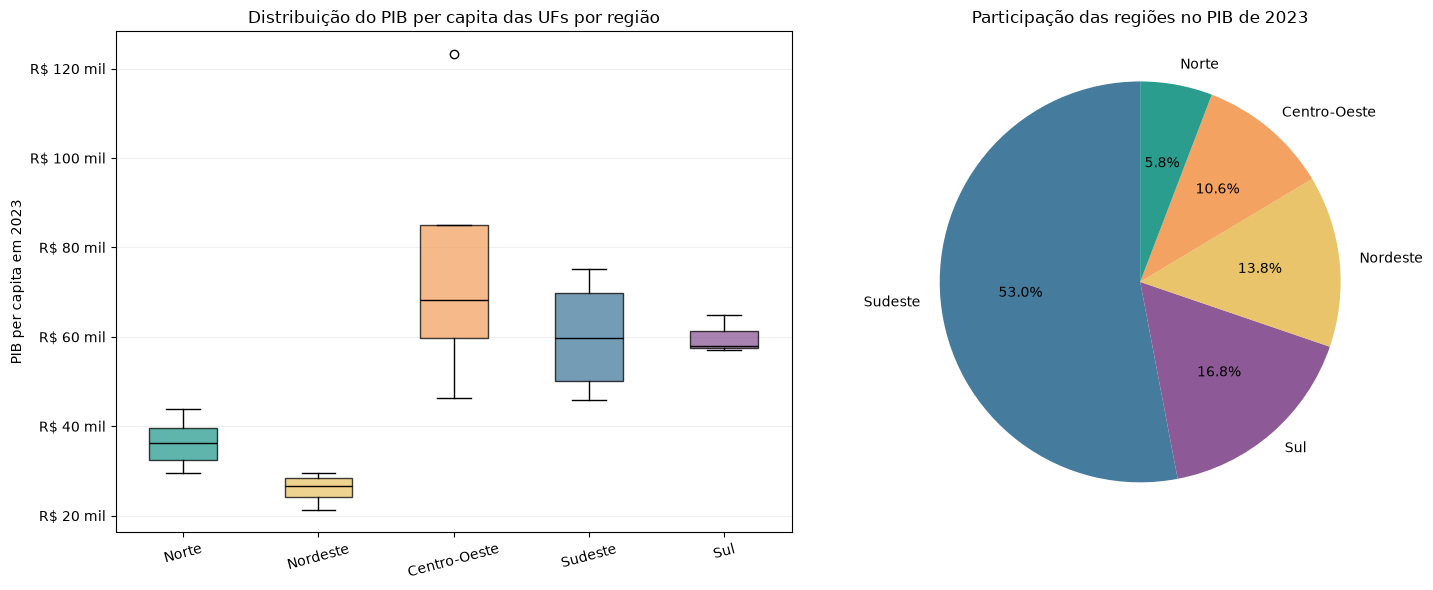

,participacao_no_pib (%)
regiao,
Sudeste,53.00
Sul,16.76
Nordeste,13.83
Centro-Oeste,10.60
Norte,5.82


In [20]:
dados_boxplot = [
    df_analise.loc[df_analise['regiao'] == regiao, 'pib_per_capita']
    for regiao in ordem_regioes
]

pib_com_regiao = df_pib_capita.copy()
pib_com_regiao['regiao'] = pib_com_regiao.index.map(regiao_por_uf)
pib_por_regiao = (
    pib_com_regiao.groupby('regiao')['pib_mil_reais']
    .sum()
    .sort_values(ascending=False)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

caixas = ax1.boxplot(dados_boxplot, patch_artist=True, medianprops={'color': 'black'})
ax1.set_xticks(range(1, len(ordem_regioes) + 1), ordem_regioes, rotation=15)
for caixa, regiao in zip(caixas['boxes'], ordem_regioes):
    caixa.set_facecolor(cores_regiao[regiao])
    caixa.set_alpha(0.75)
ax1.set_title('Distribuição do PIB per capita das UFs por região')
ax1.set_ylabel('PIB per capita em 2023')
ax1.yaxis.set_major_formatter(FuncFormatter(lambda valor, _: f'R$ {valor / 1000:.0f} mil'))
ax1.grid(axis='y', alpha=0.2)

ax2.pie(
    pib_por_regiao,
    labels=pib_por_regiao.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[cores_regiao[regiao] for regiao in pib_por_regiao.index]
)
ax2.set_title('Participação das regiões no PIB de 2023')

plt.tight_layout()
plt.show()

display((pib_por_regiao / pib_por_regiao.sum() * 100).round(2).to_frame('participacao_no_pib (%)'))

**Interpretação.** O boxplot evidencia a distância entre os níveis estaduais: Centro-Oeste, Sudeste e Sul têm medianas maiores que Norte e Nordeste. O valor do Centro-Oeste é puxado para cima pelo Distrito Federal. Já a pizza mostra forte concentração da atividade econômica: o **Sudeste reúne aproximadamente 53,0%** do PIB analisado, enquanto Nordeste e Norte respondem por cerca de **13,8% e 5,8%**, respectivamente.

### Mapa coroplético: PIB per capita por UF

A malha simplificada das UFs foi obtida na API oficial do IBGE e salva na pasta `datas`, permitindo executar o notebook sem conexão com a internet.

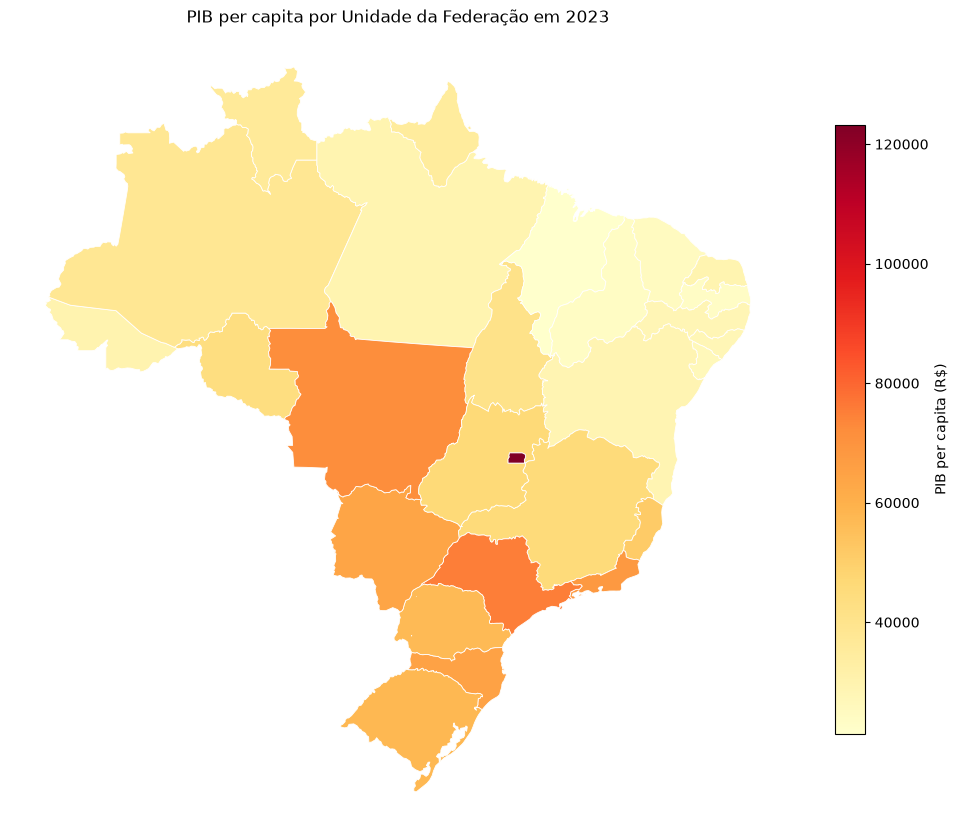

In [21]:
import geopandas as gpd

caminho_malha = Path('datas/malha_ufs.geojson')
malha_ufs = gpd.read_file(caminho_malha)

codigos_uf = (
    df_populacao_completa.loc[
        df_populacao_completa['LOCAL'].isin(df_pib_capita.index),
        ['CÓD.', 'LOCAL']
    ]
    .drop_duplicates()
    .copy()
)
codigos_uf['codarea'] = codigos_uf['CÓD.'].astype(str).str.zfill(2)
malha_ufs['codarea'] = malha_ufs['codarea'].astype(str).str.zfill(2)

mapa_pib = (
    malha_ufs
    .merge(codigos_uf[['codarea', 'LOCAL']], on='codarea', validate='one_to_one')
    .merge(
        df_pib_capita[['pib_per_capita']],
        left_on='LOCAL',
        right_index=True,
        validate='one_to_one'
    )
)

assert len(mapa_pib) == 27, 'O mapa deve conter as 27 Unidades da Federação.'

fig, ax = plt.subplots(figsize=(10, 9))
mapa_pib.plot(
    column='pib_per_capita',
    cmap='YlOrRd',
    linewidth=0.6,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'PIB per capita (R$)', 'shrink': 0.7},
    ax=ax
)
ax.set_title('PIB per capita por Unidade da Federação em 2023')
ax.axis('off')

plt.tight_layout()
plt.show()

O mapa reforça o padrão dos demais gráficos: valores mais altos aparecem no Distrito Federal e em partes do Centro-Oeste, Sudeste e Sul. Os menores valores se concentram principalmente no Nordeste. A proximidade geográfica de UFs com resultados semelhantes sugere que infraestrutura, acesso a mercados, qualificação da mão de obra e composição das atividades econômicas podem ter dimensão regional.

## Conclusões e possíveis aplicações em políticas públicas

Os resultados apontam desigualdades territoriais importantes. Distrito Federal e São Paulo aparecem entre os maiores PIBs per capita e percentuais de ensino superior completo, enquanto Maranhão está entre os menores nos dois indicadores. Além disso, a produção econômica permanece bastante concentrada no Sudeste.

Com base nesses padrões, podem ser levantadas algumas hipóteses para políticas públicas:

- ampliar acesso e permanência no ensino superior e na educação profissional em UFs com indicadores menores;
- investir em qualificação, infraestrutura e novas atividades econômicas para gerar mais oportunidades locais.;
- priorizar políticas de desenvolvimento regional sem usar apenas médias nacionais, que escondem diferenças entre UFs;
- preparar saúde, assistência e previdência para o envelhecimento e a futura redução populacional indicados pelas projeções.

### Limitações

- A análise é **estadual**, pois o arquivo de PIB já estava agregado por UF; portanto, não permite concluir sobre desigualdade entre municípios ou pessoas.
- PIB per capita mede produção econômica média e **não é renda domiciliar**, nem mostra como a riqueza é distribuída.
- Escolaridade corresponde à média dos quatro trimestres de 2023 da tabela selecionada.
- A série populacional apresenta população total, não apenas urbana, e os valores de 2023 em diante são projeções da Revisão 2024.
- Correlação indica associação, mas não demonstra causalidade.

## Referências

- [IBGE — Produto Interno Bruto dos Municípios](https://www.ibge.gov.br/estatisticas/economicas/contas-nacionais/9088-produto-interno-bruto-dos-municipios.html)
- [IBGE/SIDRA — Tabela 5919: População por nível de instrução](https://sidra.ibge.gov.br/tabela/5919)
- [IBGE — Projeções da População, Revisão 2024](https://www.ibge.gov.br/estatisticas/sociais/populacao/9109-projecao-da-populacao.html)
- [IBGE — API de Malhas Geográficas](https://servicodados.ibge.gov.br/api/docs/malhas?versao=3)